# **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# **Loading the Data**

In [43]:
df = pd.read_csv('dataset.csv', parse_dates=['Timestamp'])

# **Exploratory Data Analysis**

In [3]:
df.head()

,Timestamp,String,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current,Fault_Type
0,2025-01-01 10:33:00+05:30,String-1,760.787744,38.243446,34.654552,28.984000,9.525357,Normal
1,2025-01-01 13:15:00+05:30,String-1,956.515028,34.679934,29.085086,28.249070,11.916491,Normal
2,2025-01-01 16:44:00+05:30,String-1,859.186270,35.654215,31.332074,28.620821,10.731708,Normal
3,2025-01-01 18:38:00+05:30,String-2,965.671564,53.060418,36.606689,28.213616,12.027486,Normal
4,2025-01-01 06:07:00+05:30,String-1,618.768636,38.862544,33.687548,0.000000,12.442858,Short_Circuit


In [4]:
df.tail()

,Timestamp,String,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current,Fault_Type
2995,2025-01-01 10:45:00+05:30,String-1,685.166574,36.920355,28.089337,29.250889,8.592989,Normal
2996,2025-01-01 08:52:00+05:30,String-2,1000.000000,43.031923,28.604487,28.080105,12.442858,Normal
2997,2025-01-01 17:29:00+05:30,String-1,538.169135,31.128969,26.896630,29.723826,6.769000,Normal
2998,2025-01-01 22:00:00+05:30,String-1,869.142434,30.915886,25.299568,28.583284,10.853307,Normal
2999,2025-01-01 10:59:00+05:30,String-1,755.455005,36.551914,31.047256,29.003215,9.459752,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                    
---  ------        --------------  -----                    
 0   Timestamp     3000 non-null   datetime64[ns, UTC+05:30]
 1   String        3000 non-null   object                   
 2   Irradiance    3000 non-null   float64                  
 3   Module_Temp   3000 non-null   float64                  
 4   Ambient_Temp  3000 non-null   float64                  
 5   Voltage       3000 non-null   float64                  
 6   Current       3000 non-null   float64                  
 7   Fault_Type    3000 non-null   object                   
dtypes: datetime64[ns, UTC+05:30](1), float64(5), object(2)
memory usage: 187.6+ KB


In [6]:
df.describe()

,Irradiance,Module_Temp,Ambient_Temp,Voltage,Current
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,787.801010,36.703995,29.872898,27.496915,8.864266
std,177.115680,6.973822,4.846198,6.410831,3.253598
min,181.437087,20.705231,15.508048,0.000000,0.000000
25%,665.141039,31.816194,26.556769,28.172034,7.069049
50%,803.244014,36.086177,29.735806,28.884928,9.459752
75%,944.981521,40.563986,33.385364,29.498563,11.647694
max,1000.000000,77.499674,45.000000,30.257315,12.442858


In [7]:
df['Fault_Type'].value_counts()

,count
Fault_Type,
Normal,2152
Shading,275
Hotspot,268
Short_Circuit,153
Open_Circuit,152


<Axes: xlabel='Timestamp', ylabel='Irradiance'>

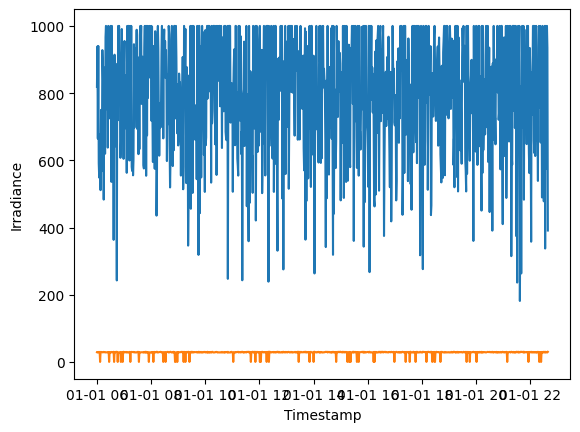

In [8]:
sns.lineplot(data=df[df['String'] == 'String-1'], x='Timestamp', y='Irradiance')
sns.lineplot(data=df[df['String'] == 'String-1'], x='Timestamp', y='Voltage')

In [9]:
fig = px.box(x='Fault_Type', y='Voltage', data_frame=df)
fig.show()

In [10]:
fig = px.box(x='Fault_Type', y='Irradiance', data_frame=df)
fig.show()

In [11]:
fig = px.box(x='Fault_Type', y='Ambient_Temp', data_frame=df)
fig.show()

In [12]:
fig = px.box(x='Fault_Type', y='Module_Temp', data_frame=df)
fig.show()

In [13]:
fig = px.box(x='String', y='Irradiance', data_frame=df, color='Fault_Type')
fig.show()

In [14]:
fig = px.box(x='String', y='Module_Temp', data_frame=df, color='Fault_Type')
fig.show()

In [15]:
fig = px.box(x='String', y='Ambient_Temp', data_frame=df, color='Fault_Type')
fig.show()

In [16]:
fig = px.box(x='String', y='Current', data_frame=df, color='Fault_Type')
fig.show()

In [17]:
fig = px.box(x='String', y='Voltage', data_frame=df, color='Fault_Type')
fig.show()

# **Distribution Analysis**

In [18]:
fig = px.histogram(
    df,
    x='Voltage',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Voltage Distribution by Fault Type'
)
fig.show()

In [19]:
fig = px.histogram(
    df,
    x='Current',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Current Distribution by Fault Type'
)
fig.show()

In [20]:
fig = px.histogram(
    df,
    x='Module_Temp',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Module Temperature Distribution by Fault Type'
)
fig.show()

In [21]:
fig = px.histogram(
    df,
    x='Ambient_Temp',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Module Temperature Distribution by Fault Type'
)
fig.show()

# **Scatterplots**

In [22]:
fig = px.scatter(
    df,
    x='Voltage',
    y='Current',
    color='Fault_Type',
    title='Current vs Voltage',
    hover_data=['Irradiance', 'Module_Temp', 'Ambient_Temp']
)
fig.show()

# **Power Analysis**

In [23]:
df['Power'] = df['Voltage'] * df['Current']

fig = px.histogram(
    df,
    x='Power',
    color='Fault_Type',
    marginal='box',
    nbins=50,
    title='Power Distribution by Fault Type'
)
fig.show()

In [24]:
numeric_cols = ['Voltage', 'Current', 'Irradiance', 'Module_Temp', 'Ambient_Temp']
df_resampled = (
    df.set_index('Timestamp')
      .groupby('String')[numeric_cols]
      .resample('1H')
      .mean()
      .reset_index()
)
fig = px.line(
    df_resampled,
    x='Timestamp',
    y='Voltage',
    color='String',
    title='Hourly Average Voltage per String'
)
fig.show()

/tmp/ipython-input-390489246.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



# **Correlation Analysis**

In [25]:
corr = df[['Voltage', 'Current', 'Irradiance', 'Module_Temp', 'Ambient_Temp']].corr()

# Plot heatmap
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    origin='upper',
    aspect='auto',
    labels=dict(color="Correlation"),
    title='Correlation Heatmap of PV Features'
)
fig.show()

In [26]:
def violin_plot(feature):
  """
  Plots a violin plot for a numerical feature by fault type
  """
  fig = px.violin(
      df,
      x='Fault_Type',
      y=feature,
      title = f'{feature} Distribution by Fault Type',
      color='Fault_Type')
  fig.show()

In [27]:
violin_plot("Current")

In [28]:
violin_plot("Voltage")

In [29]:
violin_plot("Irradiance")

In [30]:
violin_plot("Module_Temp")

In [31]:
violin_plot("Ambient_Temp")

In [34]:
def scatter(feature1, feature2):
  """
  Plots a scatterplot between 2 numerical features
  """
  fig = px.scatter(
      df,
      x=feature1,
      y=feature2,
      color='Fault_Type',
      title = f'{feature1} vs {feature2}',
      hover_data=['Irradiance', 'Module_Temp', 'Ambient_Temp'])
  fig.show()

In [38]:
scatter("Ambient_Temp", "Module_Temp")

In [39]:
scatter("Current", "Irradiance")

In [41]:
scatter("Irradiance", "Power")

In [51]:
def kde(feature):
  """
  Plots a kernel density estimate plot for a numerical feature by fault type
  """
  sns.kdeplot(
    data=df, x=feature, hue="Fault_Type",
    fill=True, common_norm=False, palette="Set2",
    alpha=.5, linewidth=0,
  )

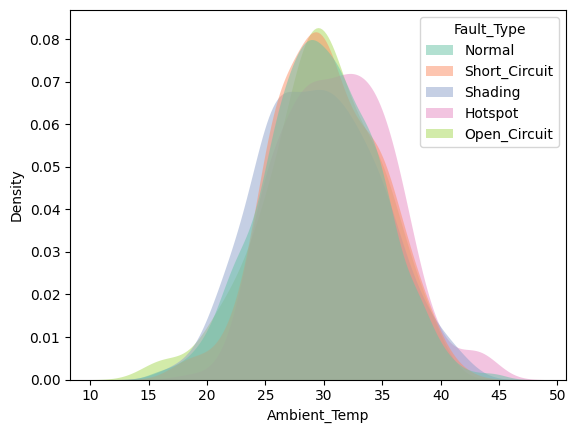

In [52]:
kde("Ambient_Temp")

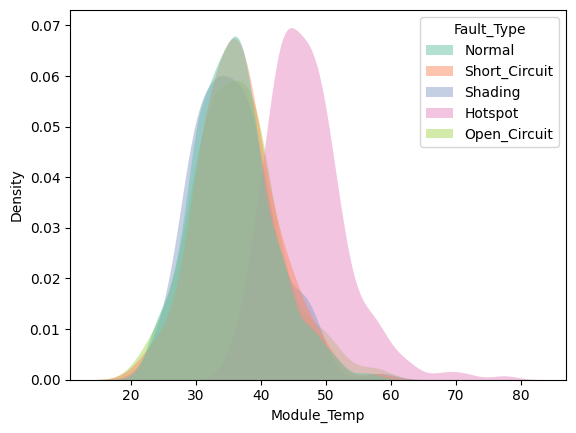

In [53]:
kde("Module_Temp")

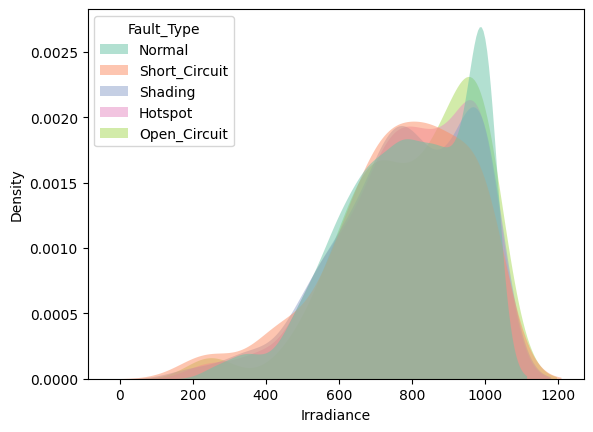

In [54]:
kde("Irradiance")

In [57]:
def time_series(feature):
  """
  Plots a time series plot for a numerical feature
  """
  fig = px.line(
      df,
      x='Timestamp',
      y=feature)
  fig.show()

In [82]:
def time_series_by_string(feature):
  """
  Plots a time series plot for a numerical feature by string
  """
  df_indexed = df.set_index('Timestamp')

    # Resample hourly within each group
  df_hourly = (
        df_indexed.groupby("String")
                  .resample('1H')[feature]
                  .mean()
                  .reset_index()
    )

  fig = px.line(
      df_hourly,
      x='Timestamp',
      y=feature,
      color="String")
  fig.show()

In [83]:
time_series_by_string("Irradiance")

/tmp/ipython-input-4247880.py:10: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [74]:
time_series_by_string("Module_Temp")

/tmp/ipython-input-3756712162.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [75]:
time_series_by_string("Ambient_Temp")

/tmp/ipython-input-3756712162.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [76]:
time_series_by_string("Voltage")

/tmp/ipython-input-3756712162.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [77]:
time_series_by_string("Current")

/tmp/ipython-input-3756712162.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [79]:
df["Irradiance_change"] = df["Irradiance"].diff()

In [90]:
def time_series_change(change):
  """
  Plots a time series plot for the change in a numericla feature
  """

  df_indexed = df.set_index('Timestamp')

    # Resample hourly within each group
  df_hourly = (
        df_indexed.groupby("String")
                  .resample('1H')[change]
                  .mean()
                  .reset_index()
    )

  fig = px.line(
      df_hourly,
      x='Timestamp',
      y=change,
      color="String")
  fig.show()

In [91]:
time_series_change("Irradiance_change")

/tmp/ipython-input-60984491.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [92]:
df['Module_Temp_change'] = df['Module_Temp'].diff()

In [93]:
time_series_change("Module_Temp_change")

/tmp/ipython-input-60984491.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [94]:
df["Ambient_Temp_change"] = df["Ambient_Temp"].diff()

In [95]:
time_series_change("Ambient_Temp_change")

/tmp/ipython-input-60984491.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [96]:
df["Voltage_change"] = df["Voltage"].diff()

In [97]:
time_series_change("Voltage_change")

/tmp/ipython-input-60984491.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [98]:
df["Current_change"] = df["Current"].diff()

In [99]:
time_series_change("Current_change")

/tmp/ipython-input-60984491.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

